In [1]:
import torch
import sys
import os
sys.path.append('..')

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

%matplotlib inline

print("Project: Efficient Deep Learning — Model Compression & Quantization")
print(f"PyTorch version : {torch.__version__}")
print(f"Device          : {'GPU' if torch.cuda.is_available() else 'CPU'}")

Project: Efficient Deep Learning — Model Compression & Quantization
PyTorch version : 2.10.0+cpu
Device          : CPU


In [2]:
results = {
    'Original'    : {'accuracy': 99.34, 'size_mb': 27.20},
    'Unstructured': {'accuracy': 99.34, 'size_mb': 27.20},
    'Structured'  : {'accuracy': 99.27, 'size_mb': 27.20},
    'PTQ'         : {'accuracy': 99.34, 'size_mb':  7.91},
    'QAT'         : {'accuracy': 99.49, 'size_mb':  7.91},
    'Student (KD)': {'accuracy': 99.04, 'size_mb':  0.43},
}

methods  = list(results.keys())
accuracy = [results[m]['accuracy'] for m in methods]
size_mb  = [results[m]['size_mb']  for m in methods]
colors   = ['#7F77DD','#C04898','#9F59D4','#1D9E75','#EF9F27','#3B8BD4']

print(f"{'Method':<16} {'Accuracy':>10} {'Size (MB)':>12} {'Compression':>14}")
print("-" * 56)
for m in methods:
    ratio = 27.20 / results[m]['size_mb']
    print(f"{m:<16} {results[m]['accuracy']:>9.2f}%"
          f" {results[m]['size_mb']:>11.2f}  {ratio:>12.1f}x")

Method             Accuracy    Size (MB)    Compression
--------------------------------------------------------
Original             99.34%       27.20           1.0x
Unstructured         99.34%       27.20           1.0x
Structured           99.27%       27.20           1.0x
PTQ                  99.34%        7.91           3.4x
QAT                  99.49%        7.91           3.4x
Student (KD)         99.04%        0.43          63.3x


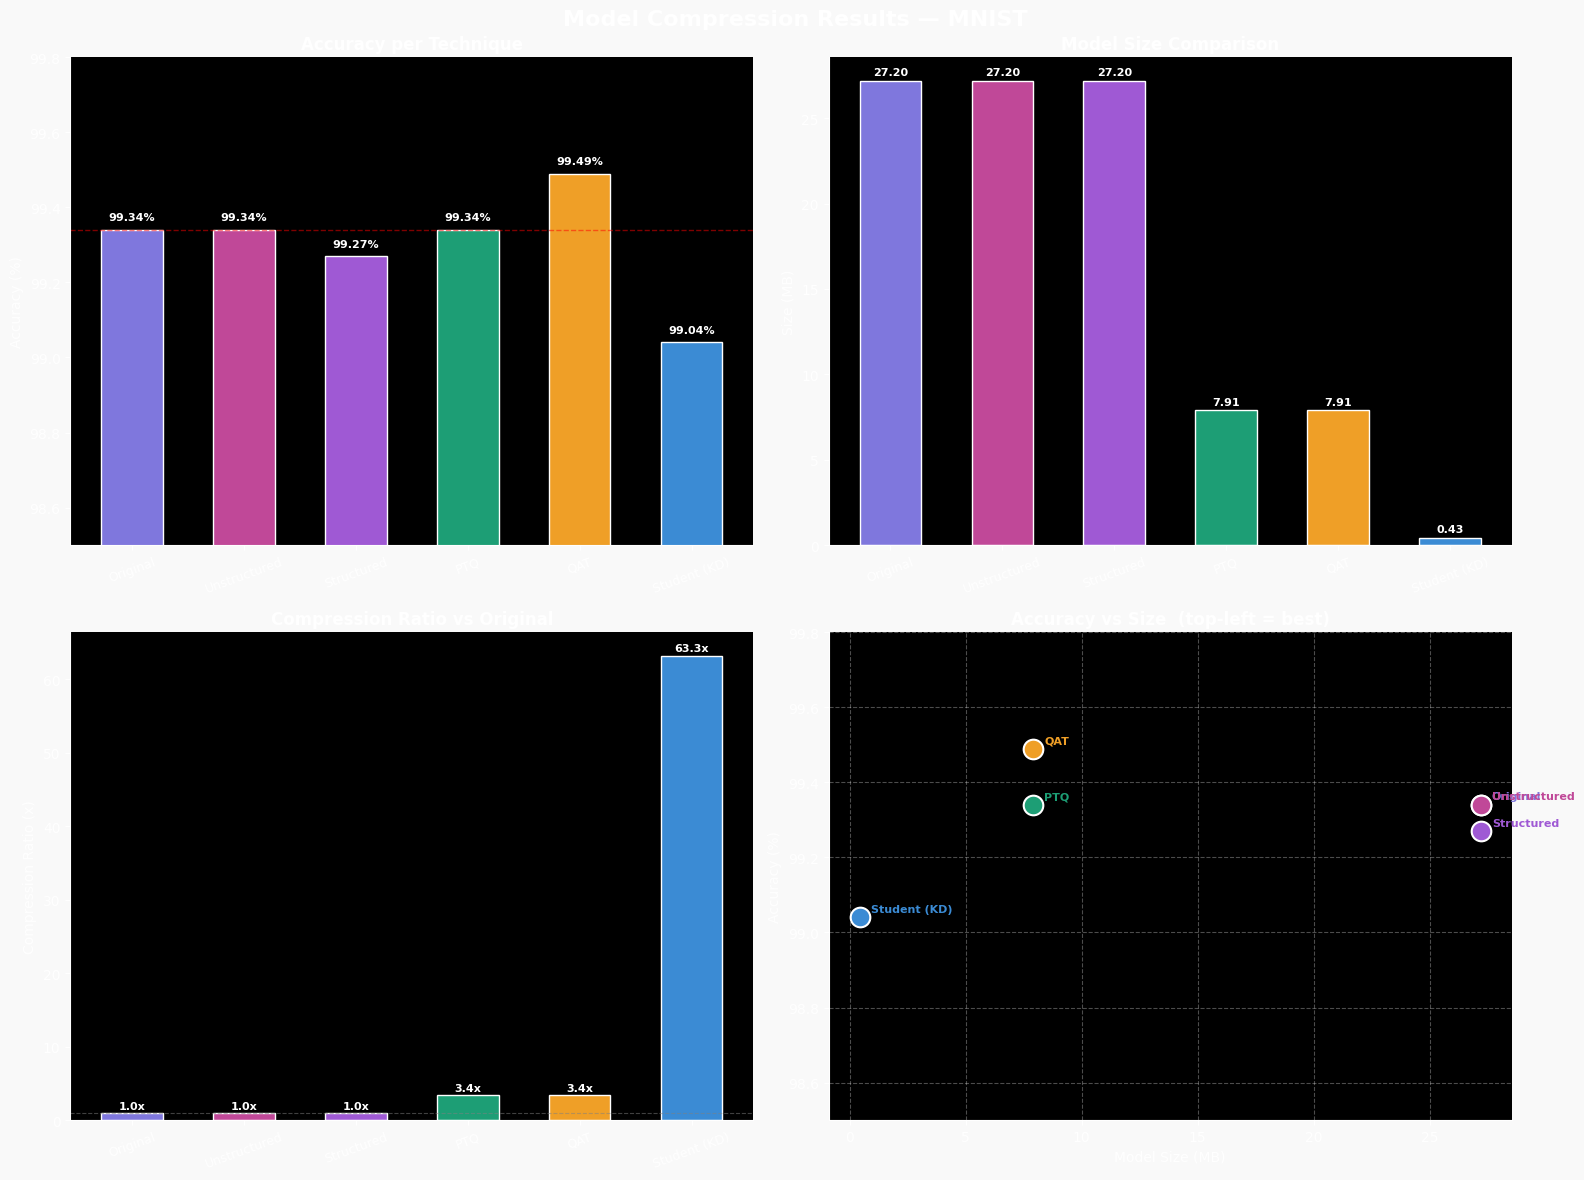

Chart saved!


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.patch.set_facecolor('#F9F9F9')
fig.suptitle('Model Compression Results — MNIST',
             fontsize=16, fontweight='bold')

ax1 = axes[0, 0]
bars = ax1.bar(methods, accuracy, color=colors, width=0.55, edgecolor='white')
ax1.set_title('Accuracy per Technique', fontweight='bold')
ax1.set_ylabel('Accuracy (%)')
ax1.set_ylim(98.5, 99.8)
ax1.tick_params(axis='x', rotation=20, labelsize=9)
ax1.spines[['top','right']].set_visible(False)
ax1.axhline(y=99.34, color='red', linestyle='--', linewidth=1, alpha=0.5)
for bar, val in zip(bars, accuracy):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.02, f'{val:.2f}%',
             ha='center', va='bottom', fontsize=8, fontweight='bold')

ax2 = axes[0, 1]
bars2 = ax2.bar(methods, size_mb, color=colors, width=0.55, edgecolor='white')
ax2.set_title('Model Size Comparison', fontweight='bold')
ax2.set_ylabel('Size (MB)')
ax2.tick_params(axis='x', rotation=20, labelsize=9)
ax2.spines[['top','right']].set_visible(False)
for bar, val in zip(bars2, size_mb):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.2, f'{val:.2f}',
             ha='center', va='bottom', fontsize=8, fontweight='bold')

ax3 = axes[1, 0]
ratios = [27.20 / s for s in size_mb]
bars3  = ax3.bar(methods, ratios, color=colors, width=0.55, edgecolor='white')
ax3.set_title('Compression Ratio vs Original', fontweight='bold')
ax3.set_ylabel('Compression Ratio (x)')
ax3.tick_params(axis='x', rotation=20, labelsize=9)
ax3.spines[['top','right']].set_visible(False)
ax3.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
for bar, val in zip(bars3, ratios):
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3, f'{val:.1f}x',
             ha='center', va='bottom', fontsize=8, fontweight='bold')

ax4 = axes[1, 1]
for i, m in enumerate(methods):
    ax4.scatter(size_mb[i], accuracy[i], color=colors[i],
                s=200, zorder=5, edgecolors='white', linewidths=1.5)
    ax4.annotate(m, (size_mb[i], accuracy[i]),
                 textcoords='offset points', xytext=(8, 4),
                 fontsize=8, color=colors[i], fontweight='bold')
ax4.set_title('Accuracy vs Size  (top-left = best)', fontweight='bold')
ax4.set_xlabel('Model Size (MB)')
ax4.set_ylabel('Accuracy (%)')
ax4.set_ylim(98.5, 99.8)
ax4.spines[['top','right']].set_visible(False)
ax4.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('../results/full_report_notebook.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [4]:
print("""
OBSERVATIONS & ANALYSIS
========================
1. PRUNING
   Unstructured (40%): No accuracy drop — model is highly redundant
   Structured   (30%): Only 0.07% drop — best for real hardware speedup

2. QUANTIZATION
   PTQ : 3.4x compression, zero accuracy loss, no retraining needed
   QAT : Same size as PTQ but +0.15% better accuracy than original

3. KNOWLEDGE DISTILLATION
   63.6x compression with only 0.30% accuracy drop
   Best for mobile and edge device deployment

CONCLUSION
==========
Best compression  → Student (KD) : 0.43 MB,  99.04%
Best accuracy     → QAT          : 7.91 MB,  99.49%
Best quick deploy → PTQ          : 7.91 MB,  99.34%
""")


OBSERVATIONS & ANALYSIS
1. PRUNING
   Unstructured (40%): No accuracy drop — model is highly redundant
   Structured   (30%): Only 0.07% drop — best for real hardware speedup

2. QUANTIZATION
   PTQ : 3.4x compression, zero accuracy loss, no retraining needed
   QAT : Same size as PTQ but +0.15% better accuracy than original

3. KNOWLEDGE DISTILLATION
   63.6x compression with only 0.30% accuracy drop
   Best for mobile and edge device deployment

CONCLUSION
Best compression  → Student (KD) : 0.43 MB,  99.04%
Best accuracy     → QAT          : 7.91 MB,  99.49%
Best quick deploy → PTQ          : 7.91 MB,  99.34%



In [5]:
from src.model import TeacherCNN, StudentCNN

teacher = TeacherCNN()
student = StudentCNN()

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("=" * 45)
print("MODEL ARCHITECTURE COMPARISON")
print("=" * 45)
print(f"Teacher CNN  : {count_parameters(teacher):,} parameters  (~27.20 MB)")
print(f"Student CNN  : {count_parameters(student):,} parameters  (~0.43  MB)")
print(f"Parameter reduction : {count_parameters(teacher)/count_parameters(student):.1f}x")
print(f"Size reduction      : {27.20/0.43:.1f}x")


MODEL ARCHITECTURE COMPARISON
Teacher CNN  : 6,797,834 parameters  (~27.20 MB)
Student CNN  : 105,866 parameters  (~0.43  MB)
Parameter reduction : 64.2x
Size reduction      : 63.3x
